# Ejercicios Prácticos - Calidad y preprocesado de datos

##### II DIPLOMA DE EXPERTO EN APRENDIZAJE AUTOMÁTICO AVANZADO EN PYTHON
#### Alumno: Pablo Fazio Arrabal

---

## Ejercicios Básicos

1.  Considere el conjunto de muestras crx.csv disponible en el Campus Virtual y realice las siguientes tareas. Ayúdese también si lo desea de la siguiente información:

    ```
    Rango de valores de los rasgos por orden de aparición y clase deseada:
    A1: b, a.
    A2: vble. numérica
    A3: vble. numérica
    A4: u, y, l, t.
    A5: g, p, gg.
    A6: c, d, cc, i, j, k, m, r, q, w, x, e, aa, ff.
    A7: v, h, bb, j, n, z, dd, ff, o.
    A8: vble. numérica
    A9: t, f.
    A10: t, f.
    A11: vble. numérica
    A12: t, f.
    A13: g, p, s.
    A14: vble. numérica
    A15: vble. numérica
    A16: +,- (clase deseada)
    
    Los valores desconocidos se han marcado con el carácter ?
    Cantidad de valores desconocidos por atributo:
    A1: 12
    A2: 12
    A4: 6
    A5: 6
    A6: 9
    A7: 9
    A14: 13
    ```

    **a)** Cargue las muestras en un DataFrame y elimine las muestras con atributos desconocidos.

    **b)** Observe los valores de las muestras del DataFrame y muestre el tipo de datos de los atributos del DataFrame. Nota: use el método `dtypes` de DataFrame. ¿Son coherentes los tipos de datos de todos los atributos con los valores que contienen?¿Por qué cree que ha sucedido esto?

    **c)** Asigne el tipo de dato adecuado a las columnas que no estén correctas. Nota: ayúdese de la función `to_numeric` de Pandas.

    **d)** Preprocese los datos para que sea posible entrenar con ellos un modelo predictivo. Explique lo que realiza y por qué.

    **e)** Divida el conjunto de datos en un 75% para entrenamiento y un 25% para test.

    **f)** Realice un escalado estándar de las muestras.

    **g)** Muestre dos gráficas comparando la distribución de muestras en el plano antes y después de escalar, elija los dos atributos numéricos que quiera. Recuerde que debe usar la misma escala en ambos ejes para que se observen las diferencias entre
    atributos. Comente si existen o no diferencias al realizar el escalado.

    **h)** Entrene dos modelos KNN, uno entrenado con las muestras originales y otro con las muestras escaladas. Compare y comente el rendimiento obtenido en test en cada caso.

In [194]:
# APARTADO A)

# Cargamos las librerías esenciales

import pandas as pd
import numpy as np

# Cargamos las muestras en el dataframe usando read_csv

df = pd.read_csv('/content/crx.csv', header=None)

df.columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16']

# Nos indican que los valores desconocidos están marcados por '?' por lo que
# los sustituimos por NaN y eliminamos aquellas muestras con algún NaN

df = df.replace(['?'], np.nan).dropna(axis=0)

df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,00202,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,00043,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,00280,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,00100,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,00120,0,+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,b,21.08,10.085,y,p,e,h,1.25,f,f,0,f,g,00260,0,-
686,a,22.67,0.750,u,g,c,v,2.00,f,t,2,t,g,00200,394,-
687,a,25.25,13.500,y,p,ff,ff,2.00,f,t,1,t,g,00200,1,-
688,b,17.92,0.205,u,g,aa,v,0.04,f,f,0,f,g,00280,750,-


In [195]:
# Comprobamos que no hay ningún valor desconocido

df.isnull().sum()

,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0
A10,0


In [196]:
# APARTADO B)

# Mostramos el tipo de dato de cada rasgo del dataframe usando dtypes

df.dtypes

,0
A1,object
A2,object
A3,float64
A4,object
A5,object
A6,object
A7,object
A8,float64
A9,object
A10,object


No son coherentes. Al observar la tabla, podemos ver que atributos como la columna ***A2*** (que contiene números decimales como 30.83) o la columna ***A14*** (que contiene códigos numéricos como 00202) deberían ser de tipo numérico (float64 o int64). Sin embargo, pandas los cataloga como tipo **object**.

Sucede pues, en un inicio, esas columnas tenían valores desconocidos marcados como **'?'**. Esto hace que probablemente pandas asignará el tipo general 'object' a la columna que mezclaba números con caracteres.

In [197]:
# APARTADO C)

# Hemos observado que las columnas A2 y A14 son aquellas que esperan un valor
# numérico y que no lo tienen luego usando to_numeric, modificamos su tipo

df['A2'] = pd.to_numeric(df['A2'])
df['A14'] = pd.to_numeric(df['A14'])

print(df.dtypes)

A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7      object
A8     float64
A9      object
A10     object
A11      int64
A12     object
A13     object
A14      int64
A15      int64
A16     object
dtype: object


In [198]:
# APARTADO D)

# En primer lugar, codifiquemos adecuadamente la clase deseada, es decir, la
# columna A16 que está compuesta por signos '+' y '-' (le asignamos manualmente
# 1 y 0 respectivamente)

mapeo_clase = {'+': 1, '-': 0}

df['A16'] = df['A16'].map(mapeo_clase)

# Ahora debemos codificar las variables categóricas de entrada (columnas A1 a
# A15 que sean de tipo object, es decir las columnas A1, A4, A5, A6, A7, A9,
# A10, A12 y A13)

# Usamos One-Hot Encoding para convertir las letras en números, como vimos en la
# práctica guiada, pandas usa la función get_dummies que transforma directamente
# las cadenas de texto a vectores de rasgo

df = pd.get_dummies(df[df.columns], drop_first=True,
               columns=['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13'])

df

,A2,A3,A8,A11,A14,A15,A16,A1_b,A4_u,A4_y,...,A7_j,A7_n,A7_o,A7_v,A7_z,A9_t,A10_t,A12_t,A13_p,A13_s
0,30.83,0.000,1.25,1,202,0,1,True,True,False,...,False,False,False,True,False,True,True,False,False,False
1,58.67,4.460,3.04,6,43,560,1,False,True,False,...,False,False,False,False,False,True,True,False,False,False
2,24.50,0.500,1.50,0,280,824,1,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,27.83,1.540,3.75,5,100,3,1,True,True,False,...,False,False,False,True,False,True,True,True,False,False
4,20.17,5.625,1.71,0,120,0,1,True,True,False,...,False,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,21.08,10.085,1.25,0,260,0,0,True,False,True,...,False,False,False,False,False,False,False,False,False,False
686,22.67,0.750,2.00,2,200,394,0,False,True,False,...,False,False,False,True,False,False,True,True,False,False
687,25.25,13.500,2.00,1,200,1,0,False,False,True,...,False,False,False,False,False,False,True,True,False,False
688,17.92,0.205,0.04,0,280,750,0,True,True,False,...,False,False,False,True,False,False,False,False,False,False


In [199]:
# Observamos la nueva lista de rasgos (importante no incluir la columna '6' con
# nombre A16 que es la clase deseada en el problema)

etiquetas_rasgos = np.concatenate((df.iloc[:, 0:6].columns,
                    df.iloc[:, 7:].columns))
etiquetas_rasgos

array(['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_b', 'A4_u', 'A4_y',
       'A5_gg', 'A5_p', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i',
       'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_dd',
       'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_t',
       'A10_t', 'A12_t', 'A13_p', 'A13_s'], dtype=object)

Es importante recalcar que hemos realizado este preprocesado ya que los algoritmos de clasificación que hemos visto funcionan mediante datos numéricos por lo que es necesario tratarlos para poder relacionar las muestras.

In [200]:
# APARTADO E)

from sklearn.model_selection import train_test_split

# Separamos los conjuntos de variables de entrada X y la columna de clase y
X = np.concatenate((df.iloc[:, 0:6].values,
                    df.iloc[:, 7:].values), axis=1)
y = df.loc[:, 'A16'].values

# Usamos train_tes_split para dividir el conjunto en 75% y 25% respectivamente
# (usamos estratificación)

X_ent, X_test, y_ent, y_test =\
    train_test_split(X, y,
                     test_size=0.25,
                     random_state=10,
                     stratify=y)

In [201]:
# APARTADO F)

# Usando directamente la biblioteca skicit-learn, realizamos escalado estándar

from sklearn.preprocessing import StandardScaler

escaladorEstandar = StandardScaler()
X_ent_std = escaladorEstandar.fit_transform(X_ent)
X_test_std = escaladorEstandar.transform(X_test)

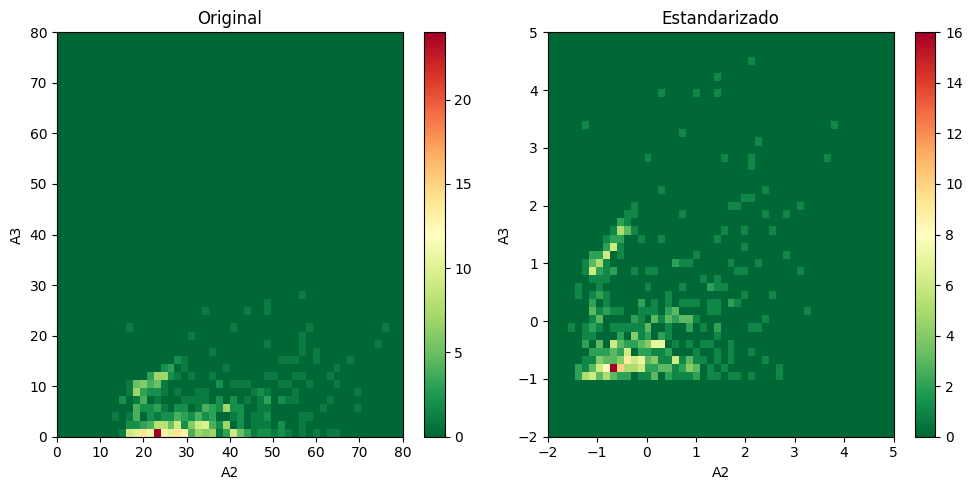

In [202]:
# APARTADO G)

import matplotlib.pyplot as plt

# Generamos una figura con dos subgráficas

fig, ax = plt.subplots(1, 2, figsize=(10, 5), tight_layout=True)

# La primera gráfica nos indica la distribución de la muestra original de los atributos
# numéricos A2 y A3 con escala [0, 80]

h1 = ax[0].hist2d(X_ent[:,0], X_ent[:,1], bins=50, cmap = "RdYlGn_r", range=[[0, 80], [0, 80]])
ax[0].set_xlabel('A2')
ax[0].set_ylabel('A3')
ax[0].set_title('Original')
fig.colorbar(h1[3], ax=ax[0])

# La segunda gráfica nos indica la distribución de la muestra estandarizada de los atributos
# numéricos A2 y A3 con escala [-2, 5]

h2 = ax[1].hist2d(X_ent_std[:,0], X_ent_std[:,1], bins=50, cmap = "RdYlGn_r", range=[[-2, 5], [-2, 5]])
ax[1].set_xlabel('A2')
ax[1].set_ylabel('A3')
ax[1].set_title('Estandarizado')
fig.colorbar(h2[3], ax=ax[1])
plt.show()

Existen diferencias entre ambas gráficas pues en la gráfica original los datos están muy alargados en el eje horizontal (pues A2 tiene una varianza mucho mayor que A3). Sin embargo, en la estandarizada los datos forman una nube de puntos más equilibrada.

In [203]:
# APARTADO H)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Entrenamiento KNN con los datos originales

knn_orig = KNeighborsClassifier(n_neighbors=5)
knn_orig.fit(X_ent, y_ent)

# Test KNN con los datos originales

y_pred_orig = knn_orig.predict(X_test)
acc_orig = accuracy_score(y_test, y_pred_orig)
print(f"Accuracy con datos originales: {acc_orig:.4f}")

# Entrenamiento KNN con los datos escalados

knn_std = KNeighborsClassifier(n_neighbors=5)
knn_std.fit(X_ent_std, y_ent)

# Test KNN con los datos escalados

y_pred_std = knn_std.predict(X_test_std)
acc_std = accuracy_score(y_test, y_pred_std)
print(f"Accuracy con datos escalados: {acc_std:.4f}")

Accuracy con datos originales: 0.6829
Accuracy con datos escalados: 0.7805


Es lógico que los datos escalados consigan una mayor precisión en la predicción de las muestras de test pues existen columnas que alcanzan valores muy grandes y dispares como la A14 o la A15.

2. Considere nuevamente el conjunto de muestras crx.csv disponible en el Campus Virtual, pero en esta ocasión realice las siguientes tareas:

    **a)** Rellene los datos incompletos empleando la media para los atributos numéricos y la moda para los no numéricos. Nota: puede utilizar los métodos `loc` o bien `iloc` de DataFrame para referenciar y rellenar aquellos atributos incompletos, dejando
    el resto de atributos inalterados.

    **b)** Asigne el tipo de dato adecuado a las columnas que no estén correctas. Preprocese los datos para que sea posible entrenar con ellos un modelo predictivo. Divida el conjunto de datos en un 75% para entrenamiento y un 25% para test. Realice un escalado estándar de las muestras.

    **c)** Aplique una selección secuencial de rasgos (SBS) utilizando neuronas logísticas como estimador. Dibuje una gráfica de exactitud en test en función de la cantidad de rasgos seleccionados. ¿Qué cantidad de rasgos es la óptima?

    **d)** Aplique una selección de rasgos significativos mediante bosques aleatorios y dibuje una gráfica que represente los atributos ordenados de mayor a menor relevancia, ponga la relevancia en el eje vertical y el rasgo en el horizontal. ¿Cuál
    es el rango más relevante?

    **e)** Utilice todos los rasgos para calcular la exactitud en test mediante un bosque
    aleatorio. Calcule la exactitud en test de un bosque con el mismo número de
    estimadores (árboles), pero esta vez use únicamente los rasgos que tienen una
    significatividad superior al 0.05. ¿Existe diferencia entre ambas exactitudes? ¿a
    qué cree que se debe? Razone sus respuestas.


In [204]:
# APARTADO A)

# En primer lugar, trabajamos como en el ejercicio 1, cargamos el dataframe
# lo renombramos e identificamos los valores desconocidos y modificamos el tipo
# a numérico de las columnas correspondientes

df_mod = pd.read_csv('/content/crx.csv', header=None)
df_mod.columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16']
df_mod = df_mod.replace('?', np.nan)
df_mod['A2'] = pd.to_numeric(df_mod['A2'])
df_mod['A14'] = pd.to_numeric(df_mod['A14'])


In [205]:
from sklearn.impute import SimpleImputer

# Definimos los completadores que usaremos como vimos en la práctica guiada
completador_numerico = SimpleImputer(missing_values=np.nan, strategy='mean')
completador_no_numerico = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

# Las columnas numéricas que necesitan de completación son las A2 y A14 como
# ya vimos en el ejercicio anterior, usamos la función fit_transform()

df_mod.loc[:, ['A2', 'A14']] = completador_numerico.fit_transform(df_mod.loc[:, ['A2', 'A14']])

# Las columnas no numéricas con datos desconocidos son las columnas A1, A4, A5, A6, A7 (basta
# observar que columnas no numéricas tienen NaN)

df_mod.loc[:, ['A1', 'A4', 'A5', 'A6', 'A7']] = completador_no_numerico.fit_transform(df_mod.loc[:, ['A1', 'A4', 'A5', 'A6', 'A7']])

# El resto de atributos se mantienen inalterados


In [206]:
# Comprobemos que ya no hay datos desconocidos

df_mod.isnull().sum()

,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0
A10,0


In [207]:
# APARTADO B)

# Trabajaremos de forma exacta que en el primer ejercicio para preparar los datos
# y dividirlos en los conjuntos de entrenamiento y test y realizar su escalado

mapeo_clase = {'+': 1, '-': 0}

df_mod['A16'] = df_mod['A16'].map(mapeo_clase)

df_mod = pd.get_dummies(df_mod[df_mod.columns], drop_first=True,
               columns=['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13'])

X_mod = np.concatenate((df_mod.iloc[:, 0:6].values,
                    df_mod.iloc[:, 7:].values), axis=1)
y_mod = df_mod.loc[:, 'A16'].values

# Usamos train_test_split para dividir el conjunto en 75% y 25% respectivamente

X_ent_mod, X_test_mod, y_ent_mod, y_test_mod =\
    train_test_split(X_mod, y_mod,
                     test_size=0.25,
                     random_state=10,
                     stratify=y_mod)

escaladorEstandar = StandardScaler()
X_ent_std_mod = escaladorEstandar.fit_transform(X_ent_mod)
X_test_std_mod = escaladorEstandar.transform(X_test_mod)

In [208]:
# APARTADO C)

# Definimos la clase SBS como hemos hecho en la práctica guiada

from sklearn.base import clone
from itertools import combinations
import numpy as np
from sklearn.metrics import accuracy_score

class SBS():
    def __init__(self, estimador, l_rasgos_obj,
                 scoring=accuracy_score):
        self.scoring = scoring
        self.estimador = clone(estimador)
        self.l_rasgos_obj = l_rasgos_obj

    def ajustar(self, X_ent, X_test, y_ent, y_test):
        # Contador de cantidad de rasgos actuales:
        k_rasgos_act = X_ent.shape[1]
        # Vector con los índices de los rasgos actuales:
        self.indices_ = tuple(range(k_rasgos_act))
        # Lista con los subconjuntos de rasgos elegidos para cada cantidad de
        # rasgos: mejores con l rasgos, con l-1, con l-2, etc:
        self.subconjuntos_ = [self.indices_]
        # Cálculo del rendimiento con el conjunto inicial de rasgos:
        rendimiento = self._calcular_rendimiento(X_ent, y_ent,
                                 X_test, y_test, self.indices_)
        # Almacenamos rendimiento inicial en la lista de rendimientos:
        self.rendimientos_ = [rendimiento]
        while k_rasgos_act > self.l_rasgos_obj:
            # Inciamos a vacío las listas de subconjuntos de rasgos con sus
            # rendimientos asociados:
            lista_rend_p = []
            subconjuntos_p = []

            # Probamos todas las combinaciones con 1 rasgo menos de los actuales
            for p in combinations(self.indices_, r=k_rasgos_act - 1):
                rendimiento_p = self._calcular_rendimiento(X_ent, y_ent,
                                         X_test, y_test, p)
                lista_rend_p.append(rendimiento_p)
                subconjuntos_p.append(p)

            # Determinarmos cuál ha sido el mejor subconjunto de rasgos:
            mejor_p = np.argmax(lista_rend_p)

            # Anotamos como mejor para esta cantidad de rasgos a mejor_p:
            self.indices_ = subconjuntos_p[mejor_p]
            self.subconjuntos_.append(self.indices_)
            self.rendimientos_.append(lista_rend_p[mejor_p])
            k_rasgos_act -= 1

        return self

    # Calcula el rendimiento de test del estimador utilizando únicamente
    # los rasgos marcados/definidos en el vector "indices"
    def _calcular_rendimiento(self, X_ent, y_train, X_test, y_test, indices):
        self.estimador.fit(X_ent[:, indices], y_train)
        y_pred = self.estimador.predict(X_test[:, indices])
        rendimiento = self.scoring(y_test, y_pred)
        return rendimiento

In [209]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Definimos una neurona logística con los parámetros de la práctica guiada
# por ejemplo

lr = LogisticRegression(penalty='l1',
                         C=1,
                         solver='liblinear')

# La entrenamos con los datos del ejercicio y usamos la clase SBS
# para aplicar selección secuencial de rasgos con neurona logística
# como estimador

lr.fit(X_ent_std_mod, y_ent_mod)
sbs = SBS(lr, l_rasgos_obj=1)
sbs.ajustar(X_ent_std_mod, X_test_std_mod, y_ent_mod, y_test_mod)

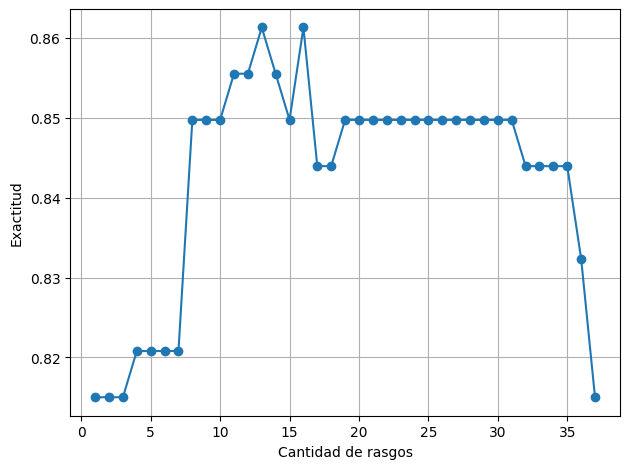

In [210]:
cantidadRasgos = [len(subconj) for subconj in sbs.subconjuntos_]
plt.plot(cantidadRasgos, sbs.rendimientos_, marker='o')
plt.ylabel('Exactitud')
plt.xlabel('Cantidad de rasgos')
plt.grid()
plt.tight_layout()
plt.show()

Según vemos en la gráfica, si escogemos alrededor de **13 o 16 rasgos** es la opción óptima en cuanto a exactitud de la predicción.

In [211]:
# APARTADO D)
from sklearn.ensemble import RandomForestClassifier

# Calculamos relevancias con un bosque aleatorio usando la práctica guiada
bosque = RandomForestClassifier(n_estimators=200,
                                random_state=10)
bosque.fit(X_ent_std_mod, y_ent_mod)
relevancias = bosque.feature_importances_

# [::-1] invierte un vector, así ordenamos de mayor a menor relevancia
indices = np.argsort(relevancias)[::-1]

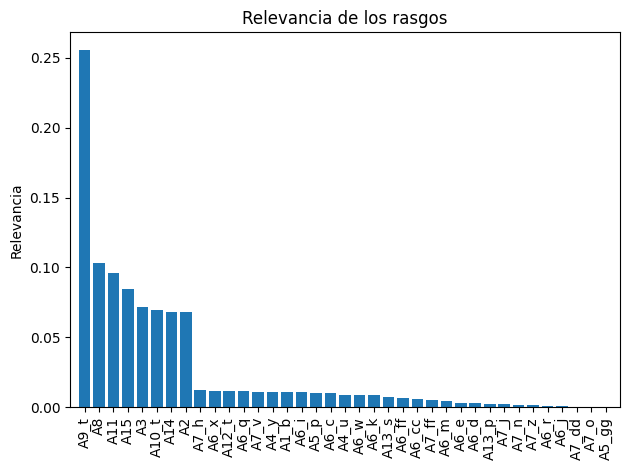

In [212]:
# Dibujamos la gráfica de relevancia de los rasgos nombrando en el eje horizontal
# cada uno de ellos y en el eje vertical su relevancia (de 0 a 1)

plt.title('Relevancia de los rasgos')
plt.bar(range(X_ent_std_mod.shape[1]),
        relevancias[indices],
        align='center')

# Mostramos etiquetas eje horizontal
plt.xticks(range(X_ent_std_mod.shape[1]),
           etiquetas_rasgos[indices], rotation=90)
plt.xlim([-1, X_ent_std_mod.shape[1]])
plt.ylabel("Relevancia")
plt.tight_layout()
plt.show()

El rasgo más relevante claramente es si **A9_t** es True o False.

In [213]:
# APARTADO E)

from sklearn.feature_selection import SelectFromModel

y_pred_todos = bosque.predict(X_test_std_mod)
acc_todos = accuracy_score(y_test_mod, y_pred_todos)
print(f"Exactitud en test con todos los rasgos: {acc_todos:.4f}")

# Identifcamos qué rasgos tienen una significatividad mayor de 0.05 usando sfm
sfm = SelectFromModel(bosque, threshold=0.05, prefit=True)

X_elegidos = sfm.transform(X_ent_std_mod)
indicesElegidos = sfm.get_support()

# Filtramos los conjuntos de datos anteriores con los rasgos seleccionados
X_ent_reducido = X_ent_std_mod[:, indicesElegidos]
X_test_reducido = X_test_std_mod[:, indicesElegidos]

# Entrenamos un nuevo bosque aleatorio con estos datos
bosque_reducido = RandomForestClassifier(n_estimators=100, random_state=1)
bosque_reducido.fit(X_ent_reducido, y_ent_mod)

y_pred_reducido = bosque_reducido.predict(X_test_reducido)
acc_reducido = accuracy_score(y_test_mod, y_pred_reducido)
print(f"Exactitud en test con selección de rasgos: {acc_reducido:.4f}")

Exactitud en test con todos los rasgos: 0.8497
Exactitud en test con selección de rasgos: 0.8150


Sí existe **diferencia**. Al fijar un umbral de 0.05, nos quedamos con un modelo más simple y rápido, pero perdemos pequeños matices de información que los otros rasgos aportaban, lo que se explica en la caída en el rendimiento en test.

## Ejercicio Avanzado

3. Considere los ficheros PoblacionINE.xlsx y ViviendasINE.xlsx disponibles en el Campus Virtual y realice las siguientes tareas:

    **a)** Cargue los datos de la población total desde PoblacionINE.xlsx a un DataFrame, los de población nacional a otro DataFrame, y los de población extranjera a un tercer DataFrame.

    **b)** Cargue los datos de las viviendas totales desde ViviendasINE.xlsx a un DataFrame, los de viviendas principales a otro DataFrame, y los de viviendas no principales a un tercer DataFrame.

    **c)** Combine con la función concat de Pandas los seis DataFrames en un solo DataFrame que tenga exactamente siete columnas: Provincia (que es el índice), PoblacionTotal, PoblacionNacional, PoblacionExtranjera, ViviendasTotales,
    ViviendasPrincipales y ViviendasNoPrincipales. Dicho DataFrame debe tener 52 filas, una por provincia.

In [214]:
# APARTADO A)

# Cargamos el archivo PoblacionINE.xlsx usando la función 'read_excel' en Pandas
# Vamos a explicar los parámetros que hemos añadido:
# - skiprows = 10, indica que debemos empezar a leer por la úndecima fila del archivo
# - nrows = 52, indica que debemos escoger las 52 filas siguientes (52 provincias)
# - header = None, el archivo no tiene fila de cabecera
# - index_col = 0, la columna 0 (provincia) es la columna índice del dataframe

df_poblacion_total = pd.read_excel('/content/PoblacionINE.xlsx', skiprows=10, nrows=52, header = None, index_col = 0)

# Nombramos la columna índice como 'Provincia'

df_poblacion_total.index.name = 'Provincia'

# Nombramos el resto de las columnas como nos sugiere el último apartado

df_poblacion_total.columns = ['PoblacionTotal']

# Mostramos las primeras filas del dataframe para comprobar el funcionamiento
df_poblacion_total.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,PoblacionTotal
Provincia,
04 Almería,730430
11 Cádiz,1249873
14 Córdoba,777622
18 Granada,925046
21 Huelva,527254


In [215]:
# Repetimos el procedimiento para Población Nacional que se encuentra entre las
# filas 64 y 115 (por eso, skiprows = 63)

df_poblacion_nacional = pd.read_excel('/content/PoblacionINE.xlsx', skiprows=63, nrows=52, header = None, index_col = 0)

df_poblacion_nacional.index.name = 'Provincia'

df_poblacion_nacional.columns = ['PoblacionNacional']

df_poblacion_nacional.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,PoblacionNacional
Provincia,
04 Almería,575979
11 Cádiz,1197787
14 Córdoba,755364
18 Granada,856272
21 Huelva,478386


In [216]:
# Repetimos el procedimiento para Población Extranjera que se encuentra entre las
# filas 117 y 168 (por eso, skiprows = 116)

df_poblacion_extranjera = pd.read_excel('/content/PoblacionINE.xlsx', skiprows=116, nrows=52, header = None, index_col = 0)

df_poblacion_extranjera.index.name = 'Provincia'

df_poblacion_extranjera.columns = ['PoblacionExtranjera']

df_poblacion_extranjera.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,PoblacionExtranjera
Provincia,
04 Almería,154451
11 Cádiz,52086
14 Córdoba,22258
18 Granada,68774
21 Huelva,48868


In [217]:
# APARTADO B)

# Repetimos el proceso para el archivo ViviendasINE.xlsx

df_viviendas_total = pd.read_excel('/content/ViviendasINE.xlsx', skiprows=8, nrows=52, header=None, index_col=0)
df_viviendas_total.index.name = 'Provincia'
df_viviendas_total.columns = ['ViviendasTotales']

df_viviendas_principal = pd.read_excel('/content/ViviendasINE.xlsx', skiprows=61, nrows=52, header=None, index_col=0)
df_viviendas_principal.index.name = 'Provincia'
df_viviendas_principal.columns = ['ViviendasPrincipales']

df_viviendas_no_principal = pd.read_excel('/content/ViviendasINE.xlsx', skiprows=114, nrows=52, header=None, index_col=0)
df_viviendas_no_principal.index.name = 'Provincia'
df_viviendas_no_principal.columns = ['ViviendasNoPrincipales']


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [218]:
# APARTADO C)

# Creamos el dataframe conjunto usando la función concat e incluyendo los
# distintos dataframe creados, como todos ellos comparten el índice 'Provincias'
# este nuevo dataframe tendrá como índice dicha columna

df_final = pd.concat([
    df_poblacion_total,
    df_poblacion_nacional,
    df_poblacion_extranjera,
    df_viviendas_total,
    df_viviendas_principal,
    df_viviendas_no_principal
], axis=1)


# Veamos la estructura del dataframe creado

df_final.head()

,PoblacionTotal,PoblacionNacional,PoblacionExtranjera,ViviendasTotales,ViviendasPrincipales,ViviendasNoPrincipales
Provincia,,,,,,
04 Almería,730430,575979,154451,434546,275726,158820
11 Cádiz,1249873,1197787,52086,648306,468478,179828
14 Córdoba,777622,755364,22258,414088,299409,114679
18 Granada,925046,856272,68774,573717,368011,205706
21 Huelva,527254,478386,48868,320916,201365,119551


In [219]:
# Comprobamos que el dataframe tiene el tamaño de filas adecuado

filas, cols = df_final.shape

print("El DataFrame tiene", filas, "filas.")

El DataFrame tiene 52 filas.


## Ejercicio Experto

4. Considere los ficheros DatosHistoricos_Eurostoxx50.csv,
DatosHistoricos_SP500.csv y DatosHistoricos_EURUSD.csv disponibles en el Campus Virtual y realice las siguientes tareas:

    **a)** Cargue los datos del índice bursátil SP500 desde DatosHistoricos_SP500.csv a un
    DataFrame, los del índice EuroStoxx50 desde DatosHistoricos_Eurostoxx50.csv
    a otro DataFrame, y los del tipo de cambio euro/dólar desde
    DatosHistoricos_EURUSD.csv a un tercer DataFrame. Tenga en cuenta que el
    campo Date de dichos ficheros es una fecha.

    **b)** Cree un DataFrame que contenga los datos de cierre (Close) de las tres series
    (SP500, EuroStoxx50 y euro/dólar), para los días que haya datos de las tres series.
    Debe usar la función merge de Pandas. El DataFrame debe tener exactamente
    cuatro columnas: Date, CloseSP500, CloseEuroStoxx50 y CloseEURUSD.
    
    **c)** Añada al DataFrame obtenido en el apartado anterior una quinta columna llamada
    CloseEuroStoxx50USD que sea el valor del índice EuroStoxx50 en dólares, es
    decir, la columna CloseEuroStoxx50 multiplicada por la columna CloseEURUSD.



In [220]:
# APARTADO A)

# Cargamos los ficheros usando la función 'read_csv' de Pandas, aquí es importante
# usar el parámetro parse_dates = ['Date'] para declarar que dicho atributo es de
# tipo fecha

df_SP500 = pd.read_csv('/content/DatosHistoricos_SP500.csv', parse_dates=['Date'])

df_EuroStoxx50 = pd.read_csv('/content/DatosHistoricos_Eurostoxx50.csv', parse_dates=['Date'])

df_EURUSD = pd.read_csv('/content/DatosHistoricos_EURUSD.csv', parse_dates=['Date'])


In [221]:
# MEJORA DE LA CALIDAD DE LOS DATOS

# Además, si observamos los datos vemos que tanto la columna 'Volume' en df_SP500
# como la columna 'Volume' en df_EURUSD son incompletas y no aportan ninguna
# información relevante así que vamos a eliminarlas

df_SP500 = df_SP500.replace(['--'], np.nan).dropna(axis=1)

df_EURUSD = df_EURUSD.dropna(axis=1)

/tmp/ipykernel_208/2349021692.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_SP500 = df_SP500.replace(['--'], np.nan).dropna(axis=1)


In [222]:
# Comprobemos que hemos creado y modificado correctamente los DataFrames

df_EuroStoxx50.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2007-03-30,4177.669922,4207.759766,4160.350098,4181.029785,4181.029785,0.0
1,2007-04-02,4177.310059,4191.759766,4163.770020,4189.549805,4189.549805,0.0
2,2007-04-03,4199.540039,4248.069824,4199.540039,4246.299805,4246.299805,0.0
3,2007-04-04,4252.709961,4261.830078,4242.049805,4261.830078,4261.830078,0.0
4,2007-04-05,4259.979980,4274.169922,4253.790039,4271.540039,4271.540039,0.0


In [223]:
# APARTADO B)

# En primer lugar, creamos los dataframes que contiene los datos de cierre y su
# fecha de cada uno de los tres dataframes anteriores. Además, es importante
# renombrar la columna 'Close' o 'Close/Last' (según fichero) con el formato
# indicado en el enunciado

df_SP500_close = df_SP500[['Date', 'Close/Last']].rename(columns={'Close/Last': 'CloseSP500'})
df_EuroStoxx50_close = df_EuroStoxx50[['Date', 'Close']].rename(columns={'Close': 'CloseEuroStoxx50'})
df_EURUSD_close = df_EURUSD[['Date', 'Close/Last']].rename(columns={'Close/Last': 'CloseEURUSD'})

# Usaremos la función 'merge' de pandas y haremos una doble llamada a la función
# Es importante notar para qué usamos cada atributo:
# - on = 'Date', significa que unimos mediante la columna 'Date'
# - how = 'inner', indicamos que devuelva solo las filas que tienen valores
# coincidentes de Date en ambas tablas

df_merged = df_SP500_close.merge(df_EuroStoxx50_close, on='Date', how='inner').merge(df_EURUSD_close,  on='Date', how='inner')


In [224]:
# Chequeamos que el funcionamiento es correcto y que hemos
# generado una tabla con las cuatro columnas requeridas y unidas
# por fecha

df_merged.head()

,Date,CloseSP500,CloseEuroStoxx50,CloseEURUSD
0,2023-07-06,4411.59,4223.089844,1.0888
1,2023-07-05,4446.82,4350.709961,1.0842
2,2023-07-03,4455.59,4398.149902,1.0907
3,2023-06-30,4450.38,4399.089844,1.0912
4,2023-06-29,4396.44,4354.689941,1.0875


In [225]:
# APARTADO C)

# Para incluir esta nueva columna en el dataframe basta definirla como sigue

df_merged['CloseEuroStoxx50USD'] = df_merged['CloseEuroStoxx50'] * df_merged['CloseEURUSD']

# Comprobamos que la columna nueva coincide con el cálculo necesario

df_merged.head()

,Date,CloseSP500,CloseEuroStoxx50,CloseEURUSD,CloseEuroStoxx50USD
0,2023-07-06,4411.59,4223.089844,1.0888,4598.100222
1,2023-07-05,4446.82,4350.709961,1.0842,4717.039740
2,2023-07-03,4455.59,4398.149902,1.0907,4797.062098
3,2023-06-30,4450.38,4399.089844,1.0912,4800.286838
4,2023-06-29,4396.44,4354.689941,1.0875,4735.725311
